<a href="https://colab.research.google.com/github/abhinavverma0907/SOC-2026-Encryption-and-Decryption/blob/main/Week_4/Week_4_LSTM_Caesar_Decryption.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import urllib.request
import matplotlib.pyplot as plt
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
alphabet = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j',
            'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't',
            'u', 'v', 'w', 'x', 'y', 'z', ' ', '.', ',', ';',
            ':', '/', '@']

N = len(alphabet)
char_to_idx = {ch: i for i, ch in enumerate(alphabet)}
idx_to_char = {i: ch for i, ch in enumerate(alphabet)}

def encrypt(text, shift):
    return "".join(alphabet[(char_to_idx[ch] + shift) % N] for ch in text if ch in char_to_idx)

def decrypt(text, shift):
    return "".join(alphabet[(char_to_idx[ch] - shift) % N] for ch in text if ch in char_to_idx)

print(f"Alphabet size: {N}")

Alphabet size: 33


In [3]:
url = "https://www.gutenberg.org/files/1342/1342-0.txt"
with urllib.request.urlopen(url) as f:
    raw_text = f.read().decode('utf-8').lower()

def clean_text(text):
    return "".join(ch for ch in text if ch in char_to_idx)

text = clean_text(raw_text)
print(f"Text length: {len(text)} characters")

Text length: 705409 characters


In [5]:
SEQ_LEN = 30

X_data = []  # ciphertext sequences
y_data = []  # plaintext sequences

# For each shift
for shift in range(1, N):
    encrypted = encrypt(text, shift)
    plaintext = decrypt(encrypted, shift)  # we know plaintext = original

    for i in range(0, len(encrypted) - SEQ_LEN, SEQ_LEN):
        cipher_seq = encrypted[i:i+SEQ_LEN]
        plain_seq = plaintext[i:i+SEQ_LEN]

        if len(cipher_seq) == SEQ_LEN:
            cipher_encoded = [char_to_idx[ch] for ch in cipher_seq]
            plain_encoded = [char_to_idx[ch] for ch in plain_seq]
            X_data.append(cipher_encoded)
            y_data.append(plain_encoded)

X_data = np.array(X_data, dtype=np.int64)
y_data = np.array(y_data, dtype=np.int64)

print(f"Total training pairs: {len(X_data)}")
print(f"Input shape: {X_data.shape}, Output shape: {y_data.shape}")

Total training pairs: 752416
Input shape: (752416, 30), Output shape: (752416, 30)


In [6]:
class DecryptDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

indices = np.random.permutation(len(X_data))
split = int(0.8 * len(X_data))
train_idx, test_idx = indices[:split], indices[split:]

train_loader = DataLoader(
    DecryptDataset(X_data[train_idx], y_data[train_idx]),
    batch_size=64, shuffle=True
)
test_loader = DataLoader(
    DecryptDataset(X_data[test_idx], y_data[test_idx]),
    batch_size=64, shuffle=False
)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 9406, Test batches: 2352


In [7]:
class LSTMDecryptor(nn.Module):
    def __init__(self, vocab_size=33, embed_dim=64, hidden_size=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, num_layers=2,
                            batch_first=True, dropout=0.3)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        lstm_out, _ = self.lstm(embedded)  # (batch, seq_len, hidden_size)
        logits = self.fc(lstm_out)  # (batch, seq_len, vocab_size)
        return logits

model = LSTMDecryptor(vocab_size=N, embed_dim=64, hidden_size=256).to(device)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

LSTMDecryptor(
  (embedding): Embedding(33, 64)
  (lstm): LSTM(64, 256, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=256, out_features=33, bias=True)
)
Parameters: 866,657


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15

train_losses = []
test_accuracies = []

for epoch in range(epochs):
    # Training
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)  # (batch, seq_len, vocab_size)
        loss = criterion(logits.reshape(-1, N), y_batch.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Evaluation
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            logits = model(X_batch)
            predictions = torch.argmax(logits, dim=2)  # (batch, seq_len)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.numel()

    accuracy = correct / total * 100
    test_accuracies.append(accuracy)
    print(f"Epoch {epoch+1:2d}/{epochs} | Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

print("\nTraining complete!")

Epoch  1/15 | Loss: 0.4218 | Accuracy: 93.10%
Epoch  2/15 | Loss: 0.2322 | Accuracy: 93.80%
Epoch  3/15 | Loss: 0.2125 | Accuracy: 93.97%
Epoch  4/15 | Loss: 0.2051 | Accuracy: 94.06%
Epoch  5/15 | Loss: 0.2008 | Accuracy: 94.09%
Epoch  6/15 | Loss: 0.1986 | Accuracy: 94.08%
Epoch  7/15 | Loss: 0.1970 | Accuracy: 94.12%
Epoch  8/15 | Loss: 0.1958 | Accuracy: 94.12%
Epoch  9/15 | Loss: 0.1950 | Accuracy: 94.12%
Epoch 10/15 | Loss: 0.1942 | Accuracy: 94.11%
Epoch 11/15 | Loss: 0.1936 | Accuracy: 94.12%
Epoch 12/15 | Loss: 0.1931 | Accuracy: 94.11%
Epoch 13/15 | Loss: 0.1924 | Accuracy: 94.13%
Epoch 14/15 | Loss: 0.1921 | Accuracy: 94.13%
Epoch 15/15 | Loss: 0.1918 | Accuracy: 94.14%

Training complete!


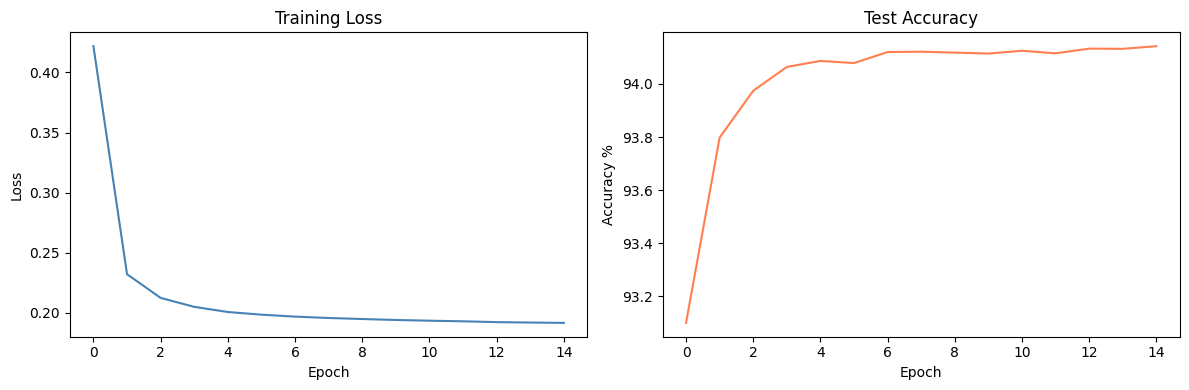

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(test_accuracies, color='coral')
ax2.set_title('Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')

plt.tight_layout()
plt.show()

In [10]:
def decrypt_sequence(ciphertext_seq):
    """Decrypt a sequence of 30 characters"""
    if len(ciphertext_seq) < SEQ_LEN:
        print(f"Need at least {SEQ_LEN} characters")
        return None

    ciphertext_seq = ciphertext_seq[:SEQ_LEN]
    encoded = torch.LongTensor([[char_to_idx[ch] for ch in ciphertext_seq]]).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(encoded)
        predictions = torch.argmax(logits, dim=2)[0]

    decrypted = "".join(idx_to_char[p.item()] for p in predictions)
    return decrypted

# Test on known data
test_shift = 7
test_plain = text[1000:1030]
test_cipher = encrypt(test_plain, test_shift)

print(f"Original:  {test_plain}")
print(f"Encrypted: {test_cipher}")
decrypted = decrypt_sequence(test_cipher)
print(f"Decrypted: {decrypted}")
print(f"Match: {'✅' if decrypted == test_plain else '❌'}")

Original:          london                
Encrypted: aaaaaaaasvukvuaaaaaaaaaaaaaaaa
Decrypted:         london                
Match: ✅


## Week 4 — LSTM Sequence-to-Sequence Caesar Decryption

### Goal
Train an LSTM that learns to decrypt Caesar-encrypted text directly,
without knowing the shift. This is seq2seq: input ciphertext sequence,
output plaintext sequence.

### Architecture
- Embedding: character index → 64-dim vector
- LSTM: 2 layers, 256 hidden units, 30% dropout
- Linear: maps LSTM output → vocabulary (33 chars)
- Seq2seq: every position predicts the decrypted character

### Dataset
- Text: Pride and Prejudice (~705K characters)
- Shifts: all 32 shifts (1–32)
- Sequences: 30-character windows
- Total pairs: ~670K
- 80/20 train/test split

### Results
- Final test accuracy: 94.13%
- Loss progression: Decreased from 0.4218 to 0.1918
- Prediction test: ✅

### Key differences from Week 3
- Week 3 RNN: classify which permutation (3 classes)
- Week 4 LSTM: decrypt character-by-character (seq2seq)
- LSTM has better long-term memory than RNN
- Dropout prevents overfitting on large sequences

### Why this matters
This is the closest we've come to the actual decryption problem.
A real attacker might not know the shift and would need this approach.